<a href="https://colab.research.google.com/github/Uzema/dsp-seminars/blob/nikolaev_lab2/seminars/2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое задание №2
## Амплитудная и фазовая модуляция: генерация, спектры, демодуляция и устойчивость к шумам

**Цель работы:**
- Научиться генерировать сигналы с амплитудной (АМ) и фазовой (ФМ) модуляцией.
- Исследовать спектральные характеристики модулированных сигналов.
- Изучить влияние индекса модуляции на спектр ФМ сигнала.
- Освоить демодуляцию АМ и ФМ с помощью преобразования Гильберта.
- Оценить устойчивость АМ и ФМ к амплитудному шуму на примере реального аудиосигнала.

**Необходимое ПО:** Python 3, библиотеки `numpy`, `matplotlib`, `scipy`, `ipywidgets`, `IPython.display`. Работа выполняется в Jupyter Notebook / Google Colab.

**Формат сдачи:** один Jupyter Notebook с кодом, графиками и текстовыми выводами. Имя файла: `2_Фамилия.ipynb`.

## Часть 1. Генерация и визуализация модулированных сигналов

### 1.1. Импорт библиотек и параметры

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from scipy.signal import hilbert
import ipywidgets as widgets
from IPython.display import Audio, display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

# Параметры дискретизации для демонстрации
fs = 10000                     # частота дискретизации (Гц)
T = 0.1                        # длительность сигнала (с)
t = np.linspace(0, T, int(fs*T), endpoint=False)

# Несущая
fc = 1000                      # частота несущей (Гц)
Ac = 1.0                       # амплитуда несущей

### 1.2. Модулирующий сигнал

В качестве модулирующего сигнала используйте сумму двух синусоид с частотами 100 Гц и 150 Гц, нормализованную к диапазону [-1, 1]. Постройте его график.

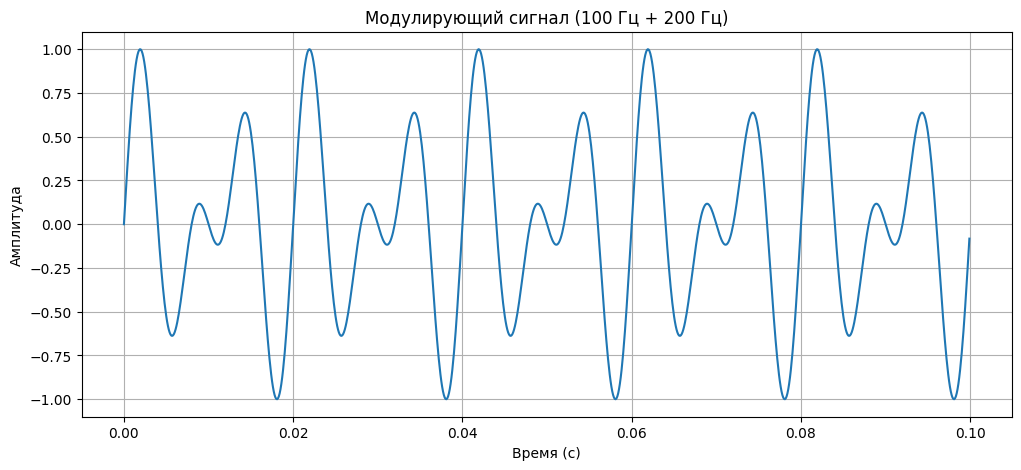

In [21]:
fm1 = 100
fm2 = 150
m_t = Ac * np.sin(2 * np.pi * fm1 * t ) + Ac * np.sin(2 * np.pi * fm2 * t ) # модулирующий сигнал - сумма двух синусоид со значениями в интервале [-1,1]
m_t = m_t / np.max(np.abs(m_t))

plt.figure()
plt.plot(t, m_t)
plt.title('Модулирующий сигнал (100 Гц + 200 Гц)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

### 1.3. Амплитудная модуляция (АМ)

Формула АМ:
$$s_{AM}(t) = A_c [1 + a_{AM}\cdot m(t)] \cos(2\pi f_c t)
$$
Параметр $a_{AM}$ регулирует _глубину модуляции_, он не может быть больше 1 (при $a_{AM}>1$ и исходном сигнале $m(t)$, нормализованном на единицу, амплитуда результирующего сигнала в некоторые промежутки времени становится отрицательной).

In [22]:
a_am = 0.2
s_am = Ac * (1 + a_am * m_t) * np.cos(2*np.pi*fc*t)

### 1.4. Фазовая модуляция (ФМ)

Формула ФМ:
$$
s_{PM}(t) = A_c \cos(2\pi f_c t + \beta \cdot m(t)),
$$

где $\beta$ – индекс фазовой модуляции.

In [23]:
beta_pm = 5
s_pm = Ac * np.cos(2*np.pi*fc*t + beta_pm * m_t)

Постройте на одном графике модулирующий сигнал и оба модулированных сигнала (АМ, ФМ). Оси и графики должны быть подписаны.

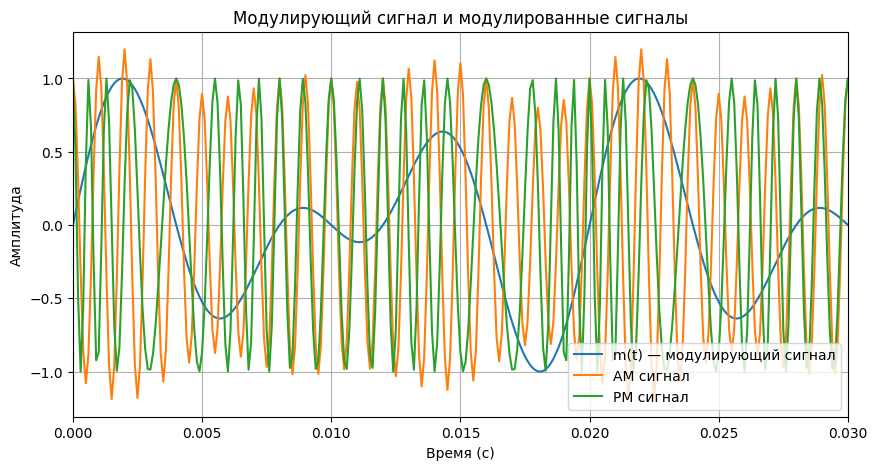

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(t, m_t,  label='m(t) — модулирующий сигнал')
plt.plot(t, s_am, label='AM сигнал')
plt.plot(t, s_pm,  label='PM сигнал')

plt.title('Модулирующий сигнал и модулированные сигналы')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')

plt.legend(loc='lower right')
plt.grid(True)

plt.xlim(0, 0.03)

plt.show()

## Часть 2. Спектральный анализ модулированных сигналов

### 2.1. Функция построения амплитудного спектра
Реализуйте функцию построения амплитудного спектра ```plot_spectrum(s,fs,title)```
Значения аргументов:
* `s` - массив, содержащий значения сигнала
* `fs` - частота отсчётов сигнала
* `title` - заголовок графика, выводимый сверху

На графике по горизонтальной оси должна быть отложена частота в герцах, а по вертикальной - амплитуда гармоники. График должен строиться только для положительных значений частоты. Оси должны быть подписаны.

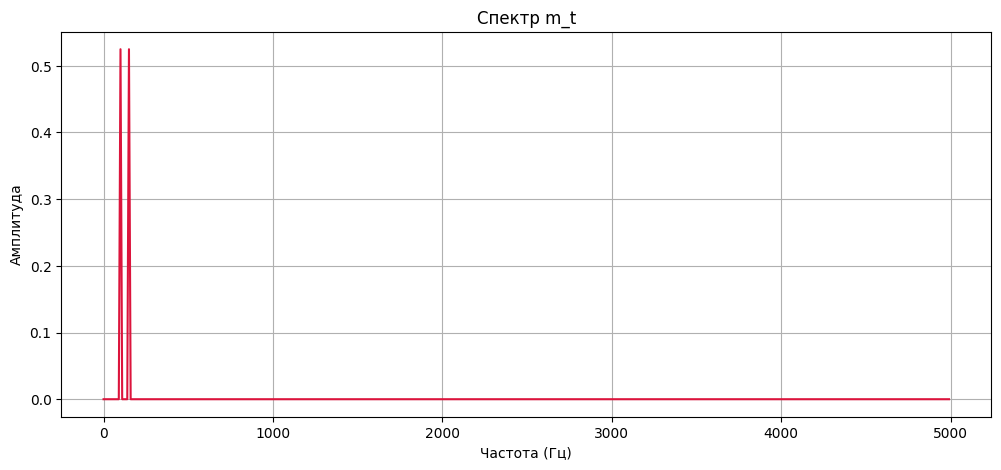

In [25]:
def plot_spectrum(s, fs, title):
  N = len(s)
  X = np.fft.fft(s)
  freq = np.fft.fftfreq(N, d=1/fs)

  half = N // 2
  freq_pos = freq[:half]
  X_mag = (2.0 / N) * np.abs(X[:half])

  plt.plot(freq_pos, X_mag, color='crimson', linewidth=1.5)
  plt.title(title)
  plt.xlabel('Частота (Гц)')
  plt.ylabel('Амплитуда')
  plt.grid(True)
  plt.show()

plot_spectrum(m_t, fs, "Спектр m_t")

### 2.2. Спектр АМ

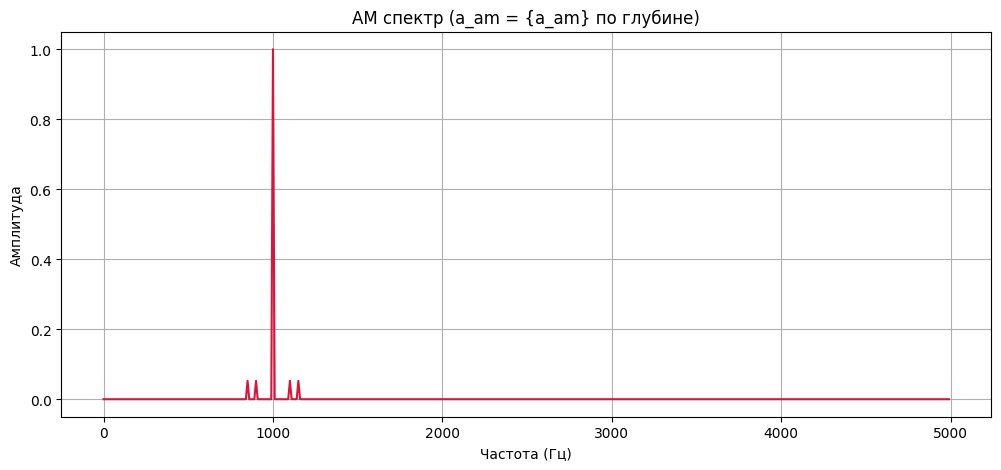

In [26]:
plot_spectrum(s_am, fs, f'АМ спектр (a_am = {a_am} по глубине)')

### 2.3. Спектр ФМ при разных индексах модуляции

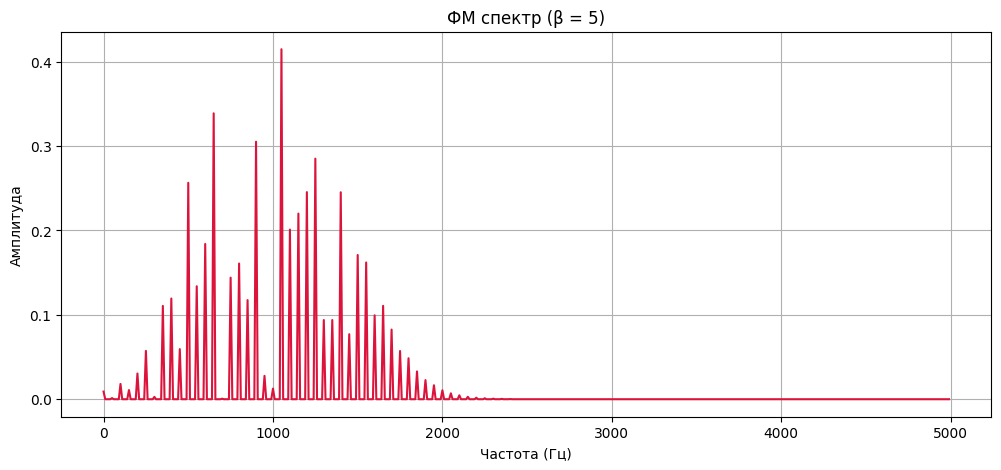

In [27]:
plot_spectrum(s_pm, fs, f'ФМ спектр (β = {beta_pm})')

Для ФМ постройте на одном графике спектры для разных индексов модуляции (например, β = 0.1, 0.3, 1, 2, 5, 10). Оси и графики должны быть подписаны.

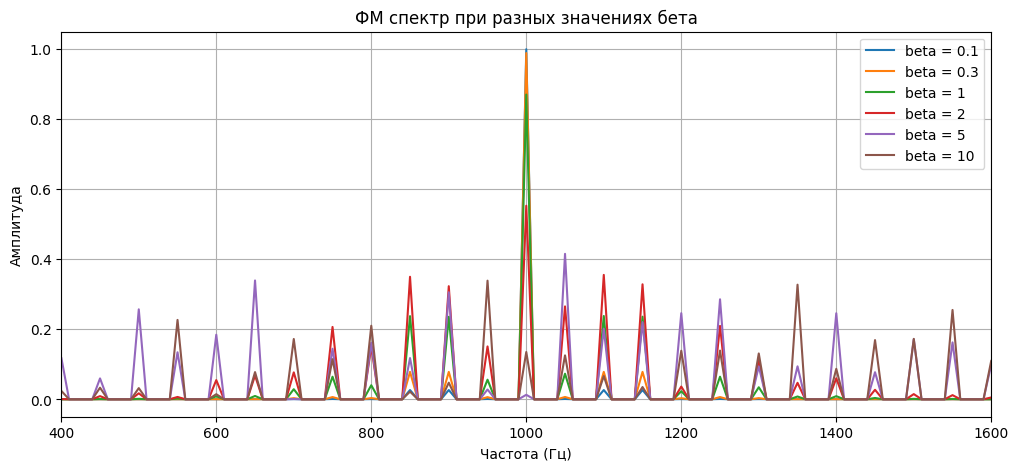

In [32]:
def plot_fm_spectrum(beta_indexes, signals, fs, fc, name_plt):
  for beta in beta_indexes:
    s_pm = 1 * np.cos(2*np.pi*fc*t + beta * signals)
    N = len(s_pm)
    X = np.fft.fft(s_pm)
    freq = np.fft.fftfreq(N, d=1/fs)
    half = N // 2
    freq_pos = freq[:half]
    X_mag = (2.0 / N) * np.abs(X[:half])
    plt.plot(freq_pos, X_mag,  label=f'beta = {beta}', linewidth=1.5)

  plt.title(name_plt)
  plt.xlabel('Частота (Гц)')
  plt.ylabel('Амплитуда')
  plt.grid(True)
  plt.legend()
  plt.xlim(fc -600, fc +600)
  plt.show()

beta_indexes = [0.1, 0.3, 1, 2, 5, 10]
plot_fm_spectrum(beta_indexes, m_t, fs, fc, "ФМ спектр при разных значениях бета")

### 2.4. Интерактивное исследование спектра ФМ
Создайте интерактивный график для исследования зависимости спектра ФМ-сигнала от индекса модуляции.

In [34]:
from ipywidgets import interact, FloatSlider

def pm_spectrum(beta=5):
  s_pm = Ac * np.cos(2 * np.pi * fc * t + beta * m_t)
  plot_spectrum(s_pm, fs, f'ФМ спектр (beta = {beta})')

widgets.interact(pm_spectrum, beta=widgets.FloatSlider(min=0.1, max=20, step=0.1, value=5));

interactive(children=(FloatSlider(value=5.0, description='beta', max=20.0, min=0.1), Output()), _dom_classes=(…

**Вопросы:**
- Почему спектр АМ содержит только пять ярко выраженных компоненты (несущая и по две боковых с каждой стороны от неё)?
- Опишите, как выглядит спектр ФМ при малых β?
- Что происходит с амплитудой несущей и боковыми полосами ФМ при увеличении β?

1. Сигнал m(t) состоит из частот 100 и 150 Гц. Спектр содержит несущую и боковые полосы ($±100$ Гц и $\pm150$ Гц от несущей)
2. При малых значениях $\beta$ спектр ФМ похож на АМ, т.к. в основном состоит из несущей и ближних к нему гармоник.
3. Уменьшается амплитуда несущей, количество боковых полос увеличивается.

## Часть 3. Демодуляция сигналов

### 3.1. Демодуляция АМ с помощью преобразования Гильберта

Преобразование Гильберта позволяет получить аналитический сигнал, огибающая которого содержит исходное сообщение.

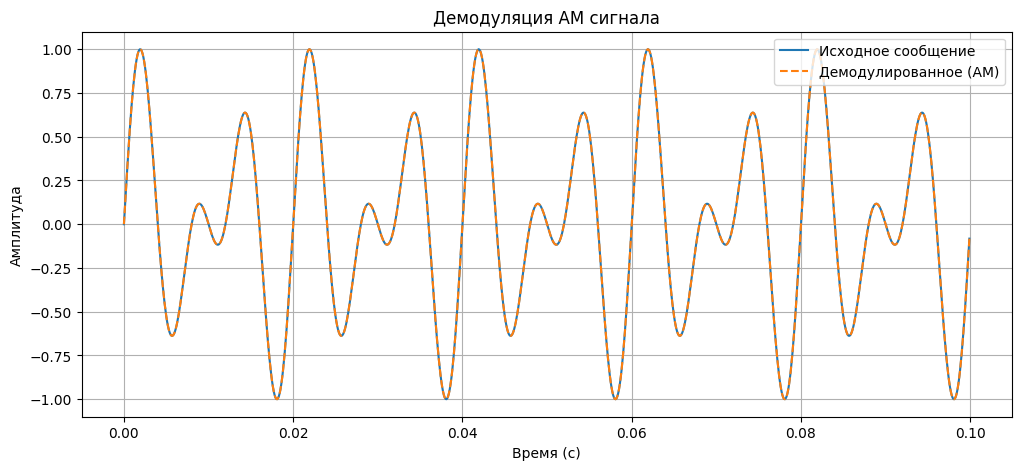

In [35]:
# Аналитический сигнал для АМ
analytic_am = hilbert(s_am)
envelope = np.abs(analytic_am) # огибающая = 1 + m(t)

# Убираем постоянную составляющую
demod_am = envelope - 1

# Нормализуем сигнал
demod_am = demod_am/a_am

# Сравнение с исходным
plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_am, '--', label='Демодулированное (АМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция АМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

Вычислите среднеквадратичную ошибку между исходным и восстановленным сообщением с помощью функции `np.std`.

In [36]:
error = np.std(m_t - demod_am)
print(f'СКО = {error:.4f}')

СКО = 0.0000


### 3.2. Демодуляция ФМ сигнала

Для ФМ информация заключена в отклонении фазы от линейного тренда. Используем аналитический сигнал и выделим мгновенную фазу.

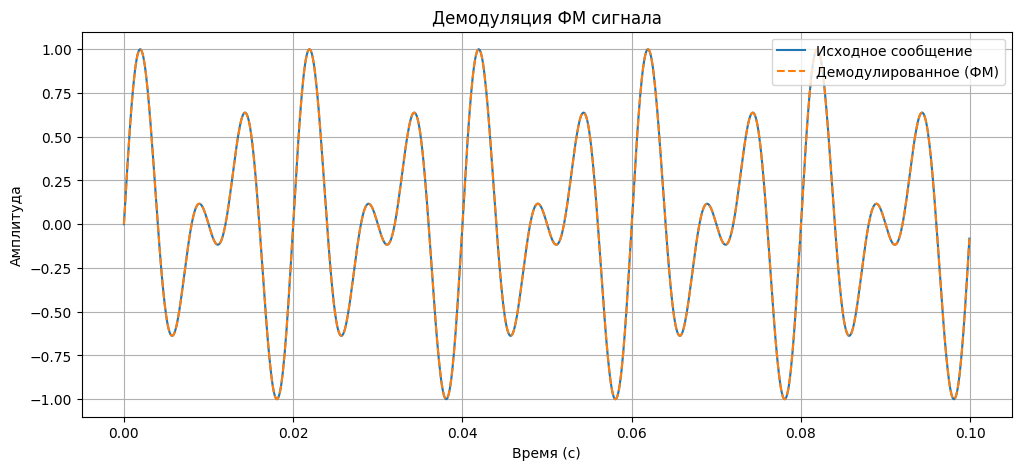

In [37]:
# Аналитический сигнал для ФМ
analytic_pm = hilbert(s_pm)
inst_phase = np.unwrap(np.angle(analytic_pm))   # развернутая фаза

# Убираем линейную составляющую (фаза несущей)
phase_no_carrier = inst_phase - 2 * np.pi * fc * t

# Убираем постоянную составляющую (может появиться в общем случае при наличии шумов, искажений и т. п.)
demod_pm = phase_no_carrier - np.mean(phase_no_carrier)

# Нормализуем сигнал
demod_pm = demod_pm / beta_pm

# Сравнение с исходным
plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_pm, '--', label='Демодулированное (ФМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция ФМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

**Вопрос:** Почему важно использовать `np.unwrap` для фазы?

`np.unwrap` важно использовать, потому функция `np.angle` ограничена диапазоном $[-\pi, \pi]$, и когда фаза пересекает этот диапазон, то возникают скачки на $2\pi$.

## Часть 4. Устойчивость к шумам

В этой части мы работаем с реальным аудиофайлом. Для примера WAV-файл расположен в том же репозитории, что и ноутбук по адресу `data/sample-3s.wav`, но его надо загрузить в Google Colab.

### 4.1. Загрузка аудио (или генерация тестового сигнала)

In [ ]:
# Загружаем файл и сохраняем под именем audio.wav
!wget -O audio.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/sample-3s.wav"

In [ ]:
fs_audio, melody_stereo = wavfile.read('audio.wav') # читаем wav-файл в массив numpy, в файл записан стереосигнал, поэтому melody_stereo будет содержать две дорожки (левую и правую)

melody = melody_stereo[:,0] # переходим к моносигналу, беря только одну из двух дорожек
melody = melody / np.max(np.abs(melody)) # нормализуем сигнал, чтобы корректно работала амплитудная модуляция

t_audio = np.linspace(0, melody.shape[0]/fs_audio, melody.shape[0], endpoint=False) # для визуализации создаём также массив временных отсчётов

print(f"Частота дискретизации: {fs_audio} Гц")
print(f"Длина временного ряда: {len(melody)}")
print(f"Тип данных: {melody.dtype}")

print("Исходное аудио:")
display(Audio(melody, rate=fs_audio))

Постройте графики самого сигнала и его спектра. Подпишите оси.

**Вопрос:** До каких частот наблюдаются заметные пики в сигнале? Подумайте, какую частоту несущей можно выбрать при частоте дискретизации 44,1 кГц, чтобы эти пики не потерять. Как на это влияет выбор индекса модуляции ФМ-сигнала?

{Введите ваш ответ здесь}

### 4.2. Подготовка к модуляции (интерполяция)

Выберите частоту несущей в соответствии с ответом на предыдущий вопрос (если восстановленный сигнал будет сильно зашумлён, попробуйте другие значения).

In [ ]:
fc_high = 5000 # несущая 5 кГц
Ac = 1

### 4.3. Модуляция аудиосигнала
Сгенерируйте модулированные сигналы. Индекс модуляции для ФМ-сигнала выберите так, чтобы несильно портить модулируемый сигнал.

In [ ]:
# АМ
a_am = 0.2
s_am_audio = Ac * (1 + a_am * melody) * np.cos(2 * np.pi * fc_high * t_audio)

# ФМ
beta_pm_audio = 2
s_pm_audio = Ac * np.cos(2 * np.pi * fc_high * t_audio + beta_pm_audio * melody)

### 4.4. Добавление шумов

**Амплитудный шум:** мультипликативный гауссов шум.

In [ ]:
noise_amp = 0.1 * np.random.randn(len(t_audio))
s_am_noisy = s_am_audio * (1 + noise_amp)
s_pm_noisy = s_pm_audio * (1 + noise_amp)

### 4.5. Демодуляция сигналов

**Демодуляция АМ:**

Используйте преобразование Гильберта, чтобы демодулировать АМ-сигнал без шума, убедитесь, что качество звука изменилось незначительно.

Демодулируйте зашумлёный АМ-сигнал.

**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $a_{AM}=0{,}2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,01. Попробуйте поменять $a_{AM}$, при каких амплитудах модуляции начинаются заметные искажения? Сделайте вывод о соотношении $a_{AM}$ и допустимых уровнях шума.

{Введите ваш ответ здесь}

**Демодуляция ФМ:**

Используйте метод аналитического сигнала для демодуляции ФМ-сигнала. Убедитесь, что качество звука изменилось незначительно.

Демодулируйте зашумлёный ФМ-сигнал.

**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $\beta=2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,1. Попробуйте поменять $\beta$. Как субъективная величина искажений зависит от $\beta$?

{Введите ваш ответ здесь}

### 4.6. Сравнение спектров

Выберите значение амплитуды шума и величин $a_{AM}$ и $\beta$ так, чтобы искажения были заметны, но не велики. Постройте спектры исходного сигнала и сигналов, восстановлённых из зашумлённых АМ и ФМ-сигналов.

**Вопрос:**
* Заметны ли визуально искажения спектров для случаев АМ и ФМ?

{Введите ваш ответ здесь}

Постройте спектры АМ и ФМ сигналов. Зафиксируйте $\beta=2$, подберите $a_{AM}$ так, чтобы амплитуды гармоник в обоих случаях были сравнимы по величине.

**Вопрос:**
* При какой амплитуде шума в этом случае вы слышите заметные искажения АМ сигнала? А ФМ сигнала? Сделайте вывод.

{Введите ваш ответ здесь}